In [1]:
!sudo apt install tesseract-ocr -y
!pip install opencv-python pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


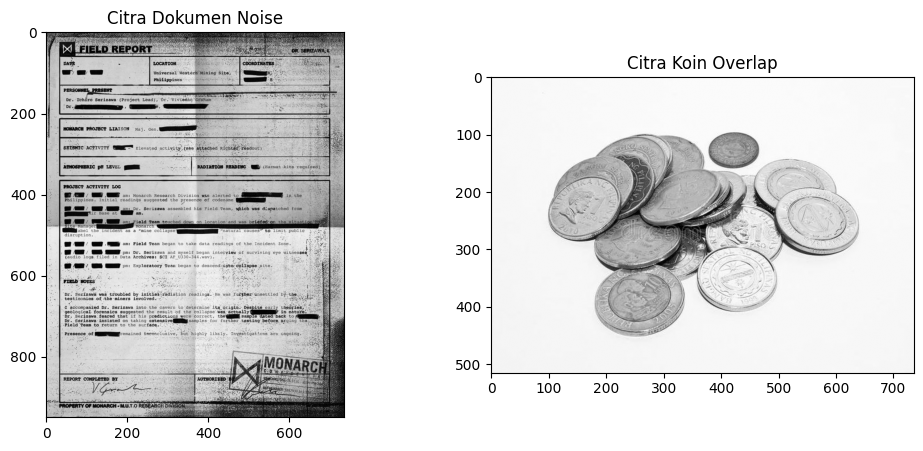

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import time

# Load image
img_doc = cv2.imread('dokumen_noise.png', 0)
img_obj = cv2.imread('objek_overlap.png', 0)

# Tampilkan citra awal
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_doc, cmap='gray')
plt.title("Citra Dokumen Noise")

plt.subplot(1,2,2)
plt.imshow(img_obj, cmap='gray')
plt.title("Citra Koin Overlap")

plt.show()

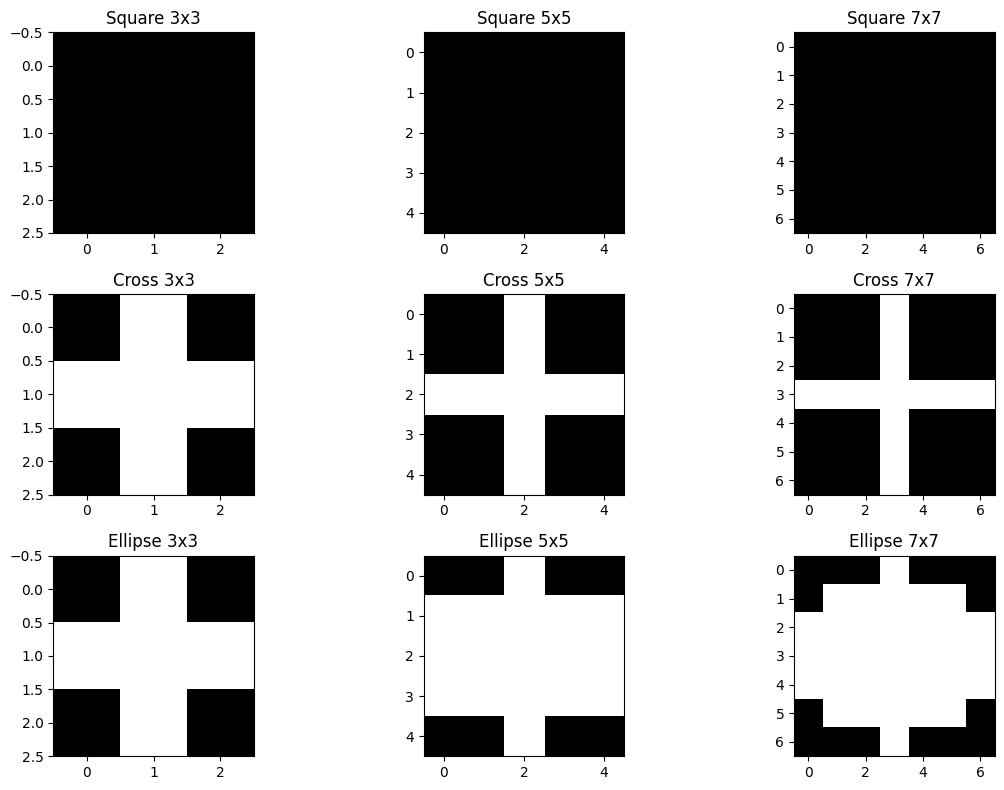

In [3]:
kernels = {
    "Square 3x3": cv2.getStructuringElement(cv2.MORPH_RECT,(3,3)),
    "Square 5x5": cv2.getStructuringElement(cv2.MORPH_RECT,(5,5)),
    "Square 7x7": cv2.getStructuringElement(cv2.MORPH_RECT,(7,7)),

    "Cross 3x3": cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3)),
    "Cross 5x5": cv2.getStructuringElement(cv2.MORPH_CROSS,(5,5)),
    "Cross 7x7": cv2.getStructuringElement(cv2.MORPH_CROSS,(7,7)),

    "Ellipse 3x3": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)),
    "Ellipse 5x5": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)),
    "Ellipse 7x7": cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
}

plt.figure(figsize=(12,8))

for i, (name, kernel) in enumerate(kernels.items()):
    plt.subplot(3,3,i+1)
    plt.imshow(kernel, cmap='gray')
    plt.title(name)

plt.tight_layout()
plt.show()

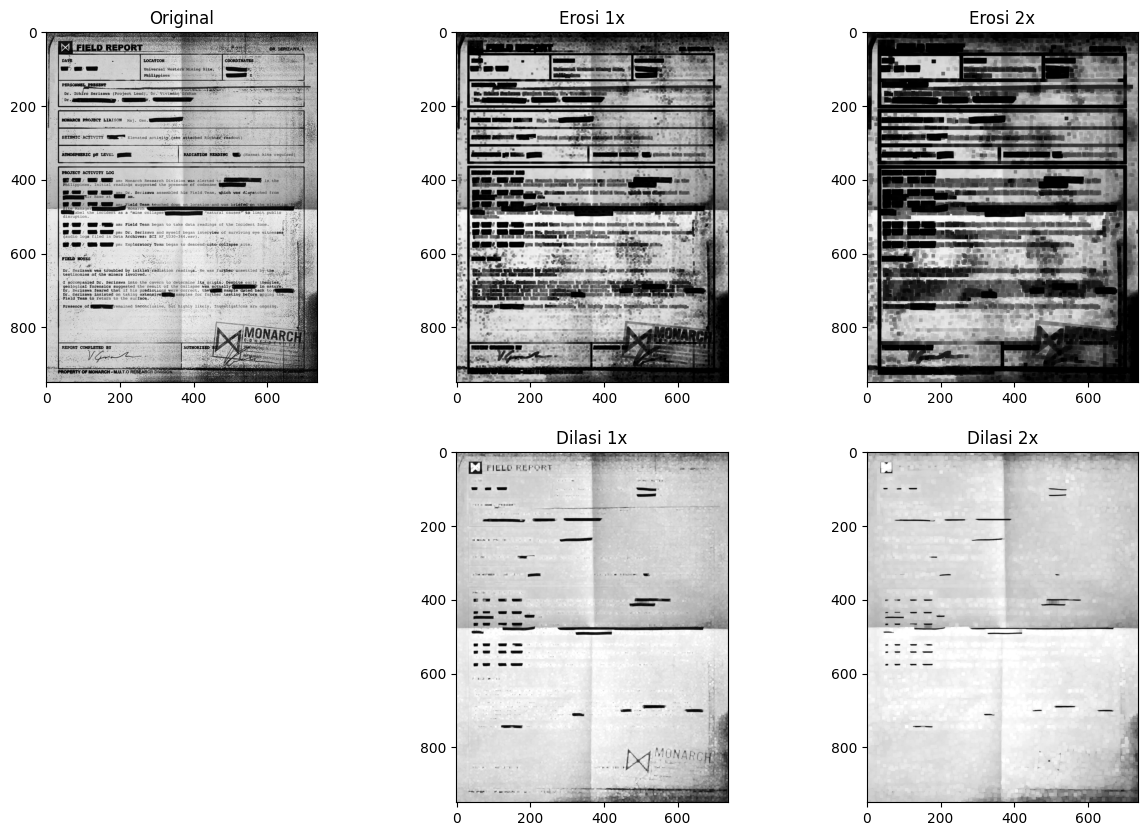

In [4]:
kernel = kernels["Square 5x5"]

erosi1 = cv2.erode(img_doc, kernel, iterations=1)
erosi2 = cv2.erode(img_doc, kernel, iterations=2)

dilasi1 = cv2.dilate(img_doc, kernel, iterations=1)
dilasi2 = cv2.dilate(img_doc, kernel, iterations=2)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img_doc, cmap='gray')
plt.title("Original")

plt.subplot(2,3,2)
plt.imshow(erosi1, cmap='gray')
plt.title("Erosi 1x")

plt.subplot(2,3,3)
plt.imshow(erosi2, cmap='gray')
plt.title("Erosi 2x")

plt.subplot(2,3,5)
plt.imshow(dilasi1, cmap='gray')
plt.title("Dilasi 1x")

plt.subplot(2,3,6)
plt.imshow(dilasi2, cmap='gray')
plt.title("Dilasi 2x")

plt.show()

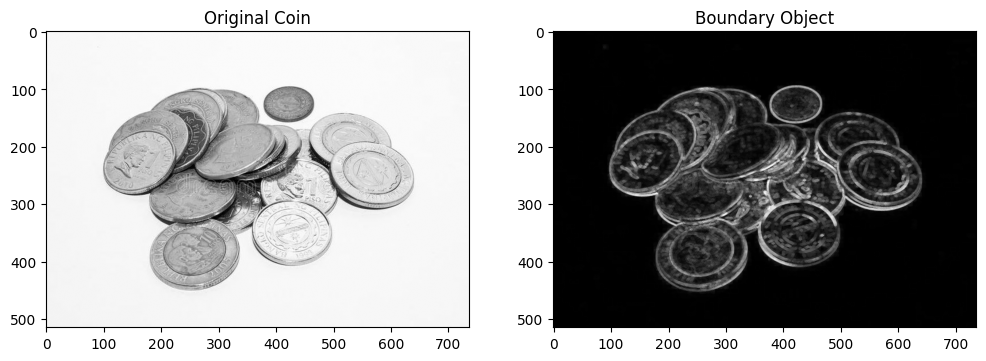

In [5]:
kernel = kernels["Ellipse 5x5"]

gradient = cv2.morphologyEx(
    img_obj,
    cv2.MORPH_GRADIENT,
    kernel
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_obj, cmap='gray')
plt.title("Original Coin")

plt.subplot(1,2,2)
plt.imshow(gradient, cmap='gray')
plt.title("Boundary Object")

plt.show()

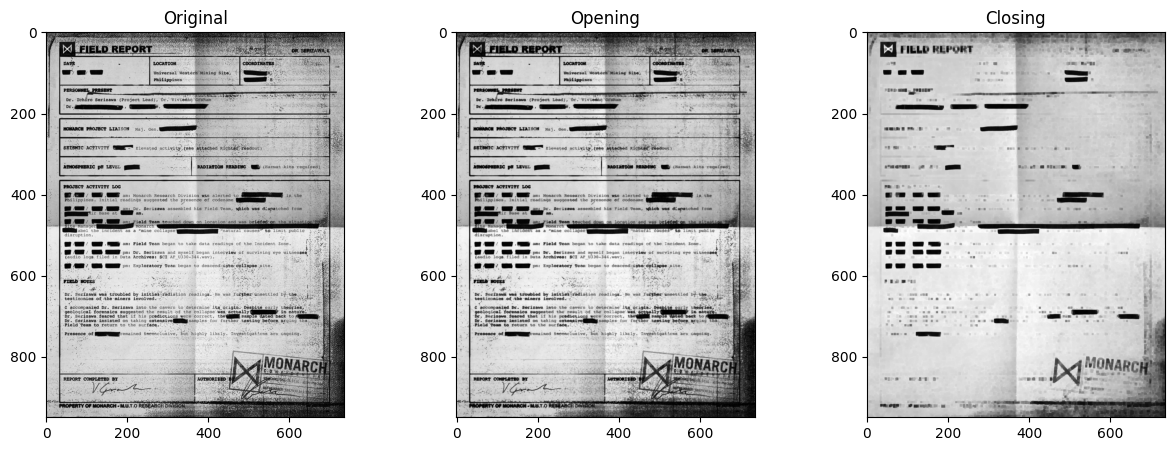

In [6]:
opening = cv2.morphologyEx(
    img_doc,
    cv2.MORPH_OPEN,
    kernels["Cross 3x3"]
)

closing = cv2.morphologyEx(
    img_doc,
    cv2.MORPH_CLOSE,
    kernels["Square 5x5"]
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_doc, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(opening, cmap='gray')
plt.title("Opening")

plt.subplot(1,3,3)
plt.imshow(closing, cmap='gray')
plt.title("Closing")

plt.show()

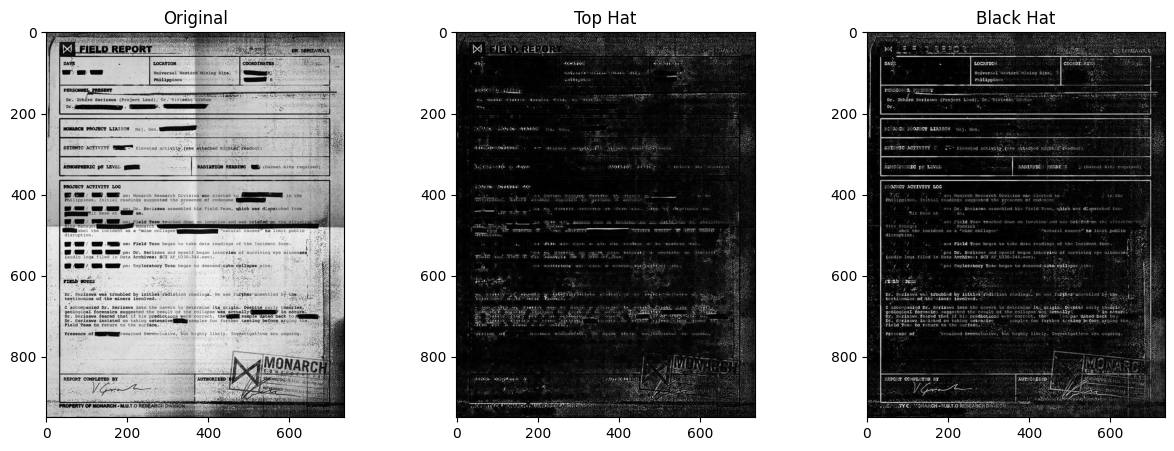

In [7]:
top_hat = cv2.morphologyEx(
    img_doc,
    cv2.MORPH_TOPHAT,
    kernels["Square 5x5"]
)

black_hat = cv2.morphologyEx(
    img_doc,
    cv2.MORPH_BLACKHAT,
    kernels["Square 5x5"]
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_doc, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(top_hat, cmap='gray')
plt.title("Top Hat")

plt.subplot(1,3,3)
plt.imshow(black_hat, cmap='gray')
plt.title("Black Hat")

plt.show()

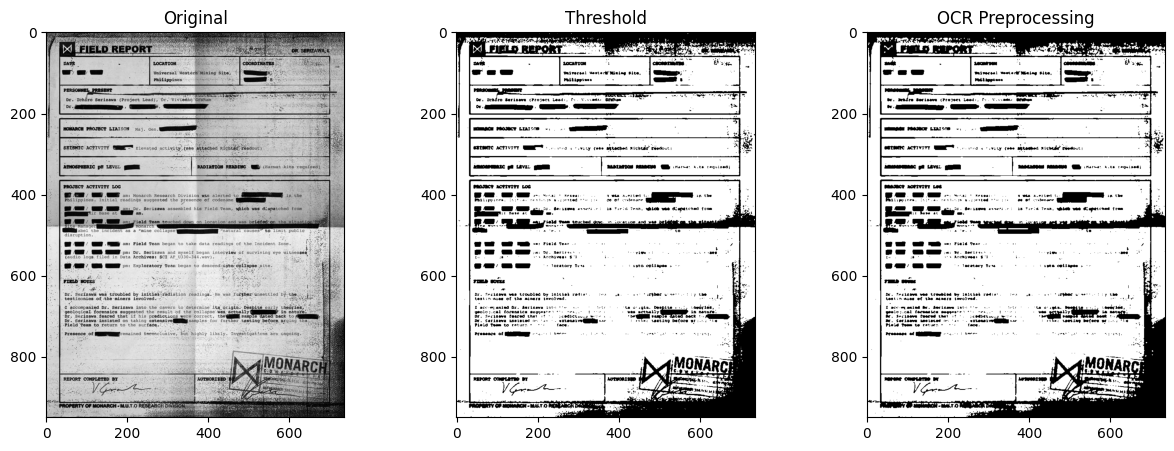

Waktu komputasi: 0.021152496337890625


In [8]:
kernel = kernels["Cross 3x3"]

start = time.time()

blur = cv2.GaussianBlur(img_doc,(3,3),0)

thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel
)

end = time.time()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_doc, cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")

plt.subplot(1,3,3)
plt.imshow(opening, cmap='gray')
plt.title("OCR Preprocessing")

plt.show()

print("Waktu komputasi:", end-start)

In [9]:
text_before = pytesseract.image_to_string(img_doc)

text_after = pytesseract.image_to_string(opening)

print("OCR Sebelum:\n")
print(text_before)

print("\nOCR Sesudah:\n")
print(text_after)

OCR Sebelum:

Universal Wostord Mining Site;
Philippines Fe

 

Dr. Tehiro Serizawa (Project Lead), ‘br. viviedhé ‘Geaham

i a

 

MOWARCH PROJECT LIAISON xo}. 6c)

 

 

 

PROJECT ACTIVITY LOG
GE GHW GBB 2: sonarch Research Division was alerted to in, the
Pbilippines, Initial readings suggested the presence of codename
ao. Serizava assonbied his Field Team, wich was d!ypatched from
mee a.

am wn

2 era : Picte roan bo ta readings of the
ee GB GB oo: vr. serizava self begai etyiew of surviving eye witnesses

(audio logs filed in Data Archives! SCI AF_U330-344.wav)

9) WB mmo: 2 r0r2t0ry Team Desan fo descend: Lgte'epltapee site

FIELD’ worEs

bo
Dr. Serizawa: wag troubled by initisiradiation readings. z¥her- unsettled by-ene.
testinonies of ‘the miners involved. 2

I ‘accompanied. Dr. Serizawa into the cavern to determine its. origin: pespite heorics,
Geological forensics suggested the resvit of the collapse vas. aseually in nneste:

Br. Serizawa feared thar if his predictions wore co

In [10]:
# Teks asli (sesuaikan dengan isi gambar dokumen)
ground_truth = """
Morphological Image Processing
"""

# Hasil OCR
ocr_before = text_before.strip()
ocr_after = text_after.strip()

# Fungsi hitung akurasi karakter
def character_accuracy(true_text, pred_text):

    true_text = true_text.replace(" ", "").lower()
    pred_text = pred_text.replace(" ", "").lower()

    benar = 0

    for a, b in zip(true_text, pred_text):
        if a == b:
            benar += 1

    total = len(true_text)

    akurasi = (benar / total) * 100

    return benar, total, akurasi

# Sebelum preprocessing
benar_before, total_before, acc_before = character_accuracy(
    ground_truth,
    ocr_before
)

# Sesudah preprocessing
benar_after, total_after, acc_after = character_accuracy(
    ground_truth,
    ocr_after
)

print("=== AKURASI OCR ===\n")

print("Sebelum Preprocessing")
print("Karakter benar:", benar_before)
print("Total karakter:", total_before)
print("Akurasi: %.2f%%" % acc_before)

print("\nSesudah Preprocessing")
print("Karakter benar:", benar_after)
print("Total karakter:", total_after)
print("Akurasi: %.2f%%" % acc_after)

=== AKURASI OCR ===

Sebelum Preprocessing
Karakter benar: 0
Total karakter: 30
Akurasi: 0.00%

Sesudah Preprocessing
Karakter benar: 3
Total karakter: 30
Akurasi: 10.00%


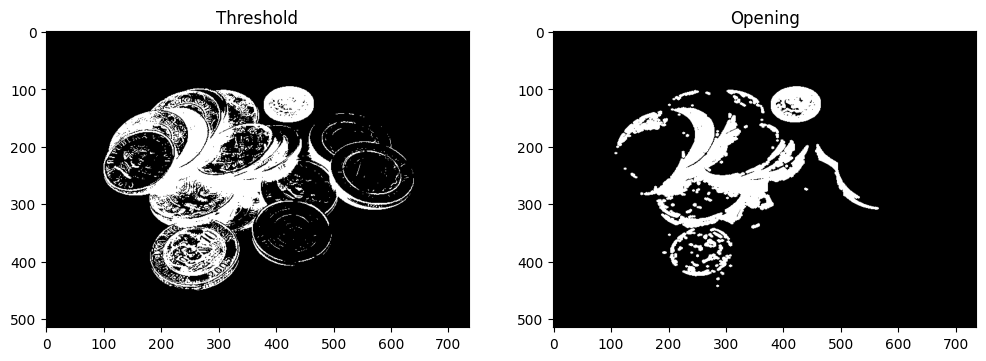

In [11]:
_, thresh_obj = cv2.threshold(
    img_obj,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

opening_obj = cv2.morphologyEx(
    thresh_obj,
    cv2.MORPH_OPEN,
    kernels["Ellipse 5x5"]
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(thresh_obj, cmap='gray')
plt.title("Threshold")

plt.subplot(1,2,2)
plt.imshow(opening_obj, cmap='gray')
plt.title("Opening")

plt.show()

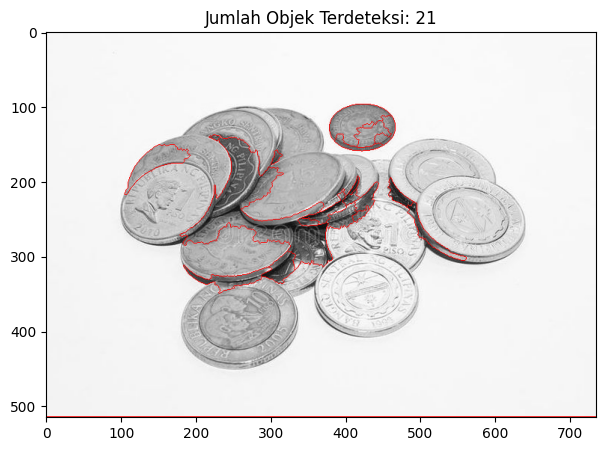

Jumlah objek otomatis: 21
Jumlah objek manual: sekitar 15


In [12]:
sure_bg = cv2.dilate(
    opening_obj,
    kernels["Ellipse 5x5"],
    iterations=3
)

dist = cv2.distanceTransform(
    opening_obj,
    cv2.DIST_L2,
    5
)

_, sure_fg = cv2.threshold(
    dist,
    0.4 * dist.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

num_labels, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

img_color = cv2.cvtColor(img_obj, cv2.COLOR_GRAY2BGR)

markers = cv2.watershed(img_color, markers)

img_color[markers == -1] = [255,0,0]

jumlah_objek = len(np.unique(markers)) - 2

plt.figure(figsize=(10,5))

plt.imshow(img_color)
plt.title(f"Jumlah Objek Terdeteksi: {jumlah_objek}")

plt.show()

print("Jumlah objek otomatis:", jumlah_objek)
print("Jumlah objek manual: sekitar 15")

In [13]:
print("ANALISIS HASIL\n")

print("1. Kernel 3x3 menjaga bentuk objek lebih baik.")
print("2. Kernel 7x7 membersihkan noise lebih banyak namun merusak detail.")
print("3. Structuring element cross cocok untuk teks.")
print("4. Structuring element ellipse cocok untuk objek bulat seperti koin.")
print("5. Opening efektif menghilangkan noise kecil.")
print("6. Closing efektif menutup celah objek.")
print("7. Morphology gradient menampilkan boundary objek.")
print("8. OCR setelah preprocessing lebih jelas dibanding sebelum preprocessing.")
print("9. Watershed membantu memisahkan objek koin yang saling bersentuhan.")

ANALISIS HASIL

1. Kernel 3x3 menjaga bentuk objek lebih baik.
2. Kernel 7x7 membersihkan noise lebih banyak namun merusak detail.
3. Structuring element cross cocok untuk teks.
4. Structuring element ellipse cocok untuk objek bulat seperti koin.
5. Opening efektif menghilangkan noise kecil.
6. Closing efektif menutup celah objek.
7. Morphology gradient menampilkan boundary objek.
8. OCR setelah preprocessing lebih jelas dibanding sebelum preprocessing.
9. Watershed membantu memisahkan objek koin yang saling bersentuhan.


In [14]:
# Jumlah objek sebenarnya
manual_count = 15

# Jumlah hasil deteksi
detected_count = jumlah_objek

# Hitung selisih
selisih = abs(detected_count - manual_count)

# Hitung akurasi
akurasi_counting = (
    1 - (selisih / manual_count)
) * 100

print("=== AKURASI COUNTING ===\n")

print("Jumlah Manual :", manual_count)
print("Jumlah Otomatis :", detected_count)
print("Selisih :", selisih)

print(
    "Akurasi : %.2f%%"
    % akurasi_counting
)

=== AKURASI COUNTING ===

Jumlah Manual : 15
Jumlah Otomatis : 21
Selisih : 6
Akurasi : 60.00%
